# 07 - Nonlinear transfer and direct NSD-Imagery encoding

This notebook keeps two questions separate:

| Analysis | Readout training data | Test data | Main interpretation |
|---|---|---|---|
| A. Nonlinear transfer | core-NSD perception | held-out core NSD, then frozen NSD-Imagery | Does extra readout capacity improve perception and transfer? |
| B. Direct encoding | NSD-Imagery target means, separately by task | held-out target identities | How predictable is each task within this acquisition? |

The direct analysis never splits repeated trials. A+B has only 12 unique image predictors, so it uses nested leave-one-target-out cross-validation and reports split-half response reliability.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SUBJECT = 1
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = REPO_ROOT / 'data' / 'nsd'
WORK = REPO_ROOT / 'outputs' / '06_core_nsd_encoder' / f'subj{SUBJECT:02d}' / 'dinov2_small'
NL_WORK = WORK / 'nonlinear_residual'
DIRECT_WORK = WORK / 'direct_nsdimagery'
NL_WORK.mkdir(parents=True, exist_ok=True)
DIRECT_WORK.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO_ROOT)
print('Core work:', WORK)


Repository: /home/jovyan/NHprojectNSDimagery
Core work: /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small


## A1. Fit the residual MLP on core NSD

The model is `ridge prediction + GELU residual`. Epoch 0 is exactly ridge. Early stopping uses only validation identities; the shared-1000 core test remains untouched until the final evaluation. Added capacity is retained only if validation correlation improves.

In [2]:
RUN_NONLINEAR_FIT = True
nonlinear_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'fit_nonlinear_encoder.py'),
    '--manifest', str(WORK / f'core_subj{SUBJECT:02d}_manifest.csv'),
    '--betas', str(WORK / f'core_subj{SUBJECT:02d}_betas.npy'),
    '--coordinates', str(WORK / f'core_subj{SUBJECT:02d}_coordinates.npy'),
    '--voxel-regions', str(WORK / f'core_subj{SUBJECT:02d}_voxel_regions.csv'),
    '--features', str(WORK / 'core_features.npz'),
    '--ridge-model', str(WORK / 'encoder_model.npz'),
    '--pca-components', '512', '--hidden-width', '256', '--dropout', '0.1',
    '--learning-rate', '3e-4', '--weight-decay', '1e-4',
    '--batch-size', '128', '--max-epochs', '80', '--patience', '10',
    '--device', 'auto',
    '--output-model', str(NL_WORK / 'encoder_model.npz'),
    '--output-summary', str(NL_WORK / 'core_test_summary.json'),
    '--output-voxel-metrics', str(NL_WORK / 'core_test_voxels.csv'),
    '--output-history', str(NL_WORK / 'validation_history.csv'),
]
if RUN_NONLINEAR_FIT:
    subprocess.run(nonlinear_command, check=True)
else:
    print('Set RUN_NONLINEAR_FIT=True to train the residual model.')


epoch=001 train_mse=0.763574 validation_r=0.350177 validation_R2=0.141136
epoch=002 train_mse=0.762558 validation_r=0.350135 validation_R2=0.141110
epoch=003 train_mse=0.761901 validation_r=0.350093 validation_R2=0.140994
epoch=004 train_mse=0.760829 validation_r=0.349798 validation_R2=0.140607
epoch=005 train_mse=0.758814 validation_r=0.349592 validation_R2=0.140312
epoch=006 train_mse=0.755093 validation_r=0.349196 validation_R2=0.139797
epoch=007 train_mse=0.748375 validation_r=0.348998 validation_R2=0.139195
epoch=008 train_mse=0.738267 validation_r=0.348133 validation_R2=0.137973
epoch=009 train_mse=0.726487 validation_r=0.347002 validation_R2=0.136381
epoch=010 train_mse=0.714281 validation_r=0.345511 validation_R2=0.133995
Selected epoch 0; epoch 0 is the exact ridge baseline (device=cuda)
{
  "method": "DINOv2_PyramidResidualMLP",
  "model_type": "ridge_plus_residual_mlp",
  "ridge_reference": "/home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/enc

In [3]:
ridge_summary_path = WORK / 'core_test_summary.json'
nonlinear_summary_path = NL_WORK / 'core_test_summary.json'
if ridge_summary_path.is_file() and nonlinear_summary_path.is_file():
    ridge = json.loads(ridge_summary_path.read_text())
    nonlinear = json.loads(nonlinear_summary_path.read_text())
    core_comparison = pd.DataFrame([
        {'model': 'ridge', 'mean test correlation': ridge['test_mean_voxel_correlation'], 'mean test R2': ridge['test_mean_voxel_r2']},
        {'model': 'residual MLP', 'mean test correlation': nonlinear['nonlinear_test_mean_voxel_correlation'], 'mean test R2': nonlinear['nonlinear_test_mean_voxel_r2']},
    ])
    display(core_comparison)
    print('Accepted from validation:', nonlinear['nonlinear_accepted_on_validation'])
    print('Selected residual epochs:', nonlinear['selected_residual_epochs'])
else:
    print('Run the nonlinear fit to create the comparison.')


,model,mean test correlation,mean test R2
0,ridge,0.351581,0.14444
1,residual MLP,0.351581,0.14444


Accepted from validation: False
Selected residual epochs: 0


## A2. Freeze the selected core model and transfer it

No NSD-Imagery beta is used below to update the nonlinear model. Compare this output against the existing ridge transfer using the same target feature cache.

In [4]:
RUN_NONLINEAR_TRANSFER = False
nonlinear_transfer_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'evaluate_encoder_nsdimagery.py'),
    '--data-root', str(DATA_ROOT), '--subject', str(SUBJECT),
    '--encoder-model', str(NL_WORK / 'encoder_model.npz'),
    '--image-manifest', str(WORK / 'nsdimagery_AB_manifest.csv'),
    '--image-features', str(WORK / 'nsdimagery_AB_features.npz'),
    '--method', 'DINOv2_PyramidResidualMLP',
    '--output-prefix', str(NL_WORK / f'dinov2_residual_subj{SUBJECT:02d}'),
]
if RUN_NONLINEAR_TRANSFER:
    subprocess.run(nonlinear_transfer_command, check=True)
else:
    print('Set RUN_NONLINEAR_TRANSFER=True after the nonlinear fit.')


Set RUN_NONLINEAR_TRANSFER=True after the nonlinear fit.


## B1. Fit vision and imagery directly

The primary model is linear kernel ridge. RBF kernel ridge is a predeclared nonlinear sensitivity analysis. Both are evaluated on predictions for held-out target identities, not fitted values.

In [7]:
RUN_DIRECT_FIT = True
direct_prefix = DIRECT_WORK / f'direct_subj{SUBJECT:02d}'
direct_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'fit_nsdimagery_direct_encoder.py'),
    '--data-root', str(DATA_ROOT), '--subject', str(SUBJECT),
    '--feature-transform-model', str(WORK / 'encoder_model.npz'),
    '--image-manifest', str(WORK / 'nsdimagery_AB_manifest.csv'),
    '--image-features', str(WORK / 'nsdimagery_AB_features.npz'),
    '--tasks', 'vision', 'imagery', '--stimulus-sets', 'A', 'B',
    '--kernels', 'linear', 'rbf',
    '--alphas', '0.01,0.1,1,10,100',
    '--rbf-gamma-scales', '0.25,1,4',
    '--output-prefix', str(direct_prefix),
]
if RUN_DIRECT_FIT:
    subprocess.run(direct_command, check=True)
else:
    print('Set RUN_DIRECT_FIT=True to run nested target-identity CV.')


Nested leave-one-target-out fitting: subj01 vision linear
Nested leave-one-target-out fitting: subj01 vision rbf
Nested leave-one-target-out fitting: subj01 imagery linear
Nested leave-one-target-out fitting: subj01 imagery rbf
         method subject    task stimulus_sets        region  n_targets  n_voxels         cv_unit             outer_cv  mean_voxel_target_correlation  median_voxel_target_correlation  fraction_positive_target_correlation  mean_voxel_target_r2  median_voxel_target_r2  fraction_positive_target_r2  mean_spearman_brown_reliability  median_spearman_brown_reliability
DirectLinearKRR  subj01  vision           A+B visual_cortex         12     15724 target_identity leave_one_target_out                      -0.155375                        -0.198599                              0.303294             -0.800693               -0.597267                     0.121280                        -0.205735                           0.120002
DirectLinearKRR  subj01  vision           A+B 

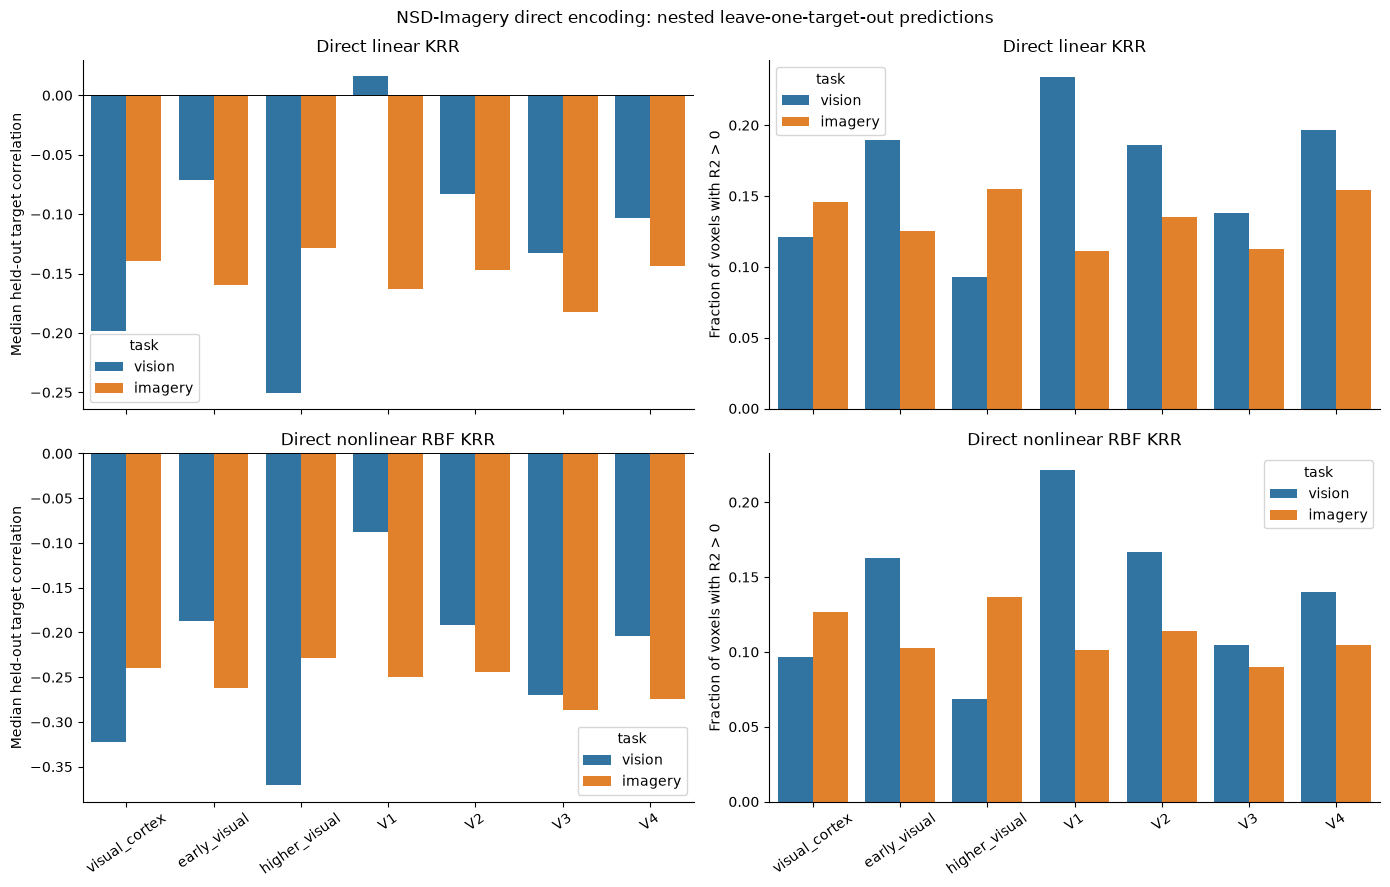

In [8]:
direct_summary_path = DIRECT_WORK / f'direct_subj{SUBJECT:02d}_summary.csv'
if direct_summary_path.is_file():
    direct = pd.read_csv(direct_summary_path)
    regions = ['visual_cortex', 'early_visual', 'higher_visual', 'V1', 'V2', 'V3', 'V4']
    direct_plot = direct[direct['region'].isin(regions)].copy()
    direct_plot['region'] = pd.Categorical(direct_plot['region'], regions, ordered=True)
    figure, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for column, ylabel, axis in [
        ('median_voxel_target_correlation', 'Median held-out target correlation', axes[0, 0]),
        ('fraction_positive_target_r2', 'Fraction of voxels with R2 > 0', axes[0, 1]),
    ]:
        sns.barplot(data=direct_plot[direct_plot['method'].eq('DirectLinearKRR')], x='region', y=column, hue='task', ax=axis)
        axis.set_ylabel(ylabel); axis.set_xlabel(''); axis.tick_params(axis='x', rotation=35)
    for column, ylabel, axis in [
        ('median_voxel_target_correlation', 'Median held-out target correlation', axes[1, 0]),
        ('fraction_positive_target_r2', 'Fraction of voxels with R2 > 0', axes[1, 1]),
    ]:
        sns.barplot(data=direct_plot[direct_plot['method'].eq('DirectRBFKRR')], x='region', y=column, hue='task', ax=axis)
        axis.set_ylabel(ylabel); axis.set_xlabel(''); axis.tick_params(axis='x', rotation=35)
    axes[0, 0].set_title('Direct linear KRR'); axes[0, 1].set_title('Direct linear KRR')
    axes[1, 0].set_title('Direct nonlinear RBF KRR'); axes[1, 1].set_title('Direct nonlinear RBF KRR')
    for axis in axes.flat:
        axis.axhline(0, color='black', linewidth=0.7)
        axis.spines[['top', 'right']].set_visible(False)
    figure.suptitle('NSD-Imagery direct encoding: nested leave-one-target-out predictions')
    figure.tight_layout()
else:
    print('Run the direct fit to create summaries.')


## B2. Create native-space direct $R^2$ maps

The direct map still uses held-out target predictions. The independent core-NSD `$R^2 > 0$` mask prevents selection on the direct imagery result itself.

In [9]:
RUN_DIRECT_MAPS = False
direct_map_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'plot_encoder_r2_maps.py'),
    '--data-root', str(DATA_ROOT), '--subject', str(SUBJECT),
    '--core-voxel-metrics', str(WORK / 'core_test_voxels.csv'),
    '--transfer-voxel-metrics', str(DIRECT_WORK / f'direct_subj{SUBJECT:02d}_voxel_metrics.csv'),
    '--vision-r2-column', 'linear_vision_target_r2',
    '--imagery-r2-column', 'linear_imagery_target_r2',
    '--analysis-label', 'NSD-Imagery direct target-CV encoding',
    '--output-dir', str(DIRECT_WORK / 'linear_r2_maps'),
]
if RUN_DIRECT_MAPS:
    subprocess.run(direct_map_command, check=True)
else:
    print('Set RUN_DIRECT_MAPS=True after direct fitting.')


Set RUN_DIRECT_MAPS=True after direct fitting.


## Interpretation checklist

1. Accept the residual MLP only from core validation; report its untouched core test result either way.
2. For analysis A, compare frozen ridge and frozen nonlinear transfer. Neither model saw NSD-Imagery betas.
3. For analysis B, use outer leave-one-target-out predictions only. Do not report in-sample fit as explained variance.
4. Compare linear and RBF direct models as predeclared alternatives, not by selecting whichever gives the preferred vision-imagery contrast.
5. Read vision-imagery differences alongside split-half reliability. Lower imagery reliability lowers the attainable score.
6. With 12 identities, single-subject voxel maps are exploratory. Subjects are the unit for group inference.